# ML HW1

313551170 王韋程

In [1]:
import sys
import os
import numpy as np
import copy
import random
import matplotlib.pyplot as plt
from tqdm import tqdm, trange

In [16]:
path = os.getcwd()
file_name = "test.txt"
base = 3
lambda_ = 10000
path += "\\" + file_name

In [11]:
data = np.loadtxt(path, delimiter=',')
X = data[:, 0]
Y = data[:, 1]
N = len(X) # number of data

A = np.zeros((N, base))
b = copy.copy(Y)
b = b.reshape(b.shape[0], 1)
for i in range(N):
    for j in range(base):
        A[i][j] = X[i]**j

In [4]:
def m_lambda_i(n, l):
    m = np.zeros((n, n))
    for i in range(n):
        m[i][i] = l

    return m

def m_mul(m1, m2):
    n_row = m1.shape[0]
    n_col = m2.shape[1]
    n_mid = m1.shape[1]
    m3 = np.zeros((n_row, n_col))
    for i in range(n_row):
        for j in range(n_col):
            sum = 0
            for k in range(n_mid):
                sum += m1[i][k]*m2[k][j]
            m3[i][j] = sum
    
    return m3

def m_add(m1, m2):
    n_row = m1.shape[0]
    n_col = m1.shape[1]
    m3 = np.zeros((n_row, n_col))
    for i in range(n_row):
        for j in range(n_col):
            m3[i][j] = m1[i][j] + m2[i][j]
    
    return m3

def m_invert(m):
    n = m.shape[0]
    m1 = copy.deepcopy(m)
    m2 = m_lambda_i(n, 1) #invert of m

    for i in range(n):
        t = m1[i][i]
        m1[i] /= t
        m2[i] /= t
        for j in range(n):
            if i != j:
                t = m1[j][i]
                m1[j] -= t * m1[i]
                m2[j] -= t * m2[i]
    
    return m2

def m_transpose(m):
    n_row, n_col = m.shape
    mt = np.zeros((n_col, n_row))
    for row in range(n_row):
        for col in range(n_col):
            mt[col][row] = m[row][col]

    return mt

In [5]:
def PrintResult(x):
    print("Fitting line: ", end='')
    for i in range(base-1, 0, -1):
        print(x[i][0], end='')
        print("x^%d + "%(i), end='')
    print(x[0][0])

    error = 0
    for i in range(N):
        f = 0
        for j in range(base):
            f += X[i]**j*x[j][0]
        
        error += (f - Y[i])**2
    
    print("Total error: %f\n"%error)

## LSE

In [17]:
print("---Computing LSE---")
    
# LSE with L2-norm
# x = (A^T * A + lambda * I)^-1 * A^T * b
AT = m_transpose(A)
m_lambda = m_lambda_i(base, lambda_)
A2 = m_add(m_mul(AT, A), m_lambda)
A2_invert = m_invert(A2)
x1 = m_mul(m_mul(A2_invert, AT), b)

print("---Finish computing LSE---")
print("LSE Result:")
PrintResult(x1)

---Computing LSE---
---Finish computing LSE---
LSE Result:
Fitting line: 0.834533282700286x^2 + 0.09314819831918814x^1 + 0.046950699273469274
Total error: 22649.738493



## Steepest Descent

In [18]:
print("---Computing Steepest Descent---")

x2 = np.array([random.random() for i in range(base)])
L = 0.00001
epochs = 100000

# Performing Gradient Descent 
for i in trange(epochs): 
    Y_pred = np.zeros(N)
    for j in range(N):
        for k in range(base):
            Y_pred[j] += x2[k] * X[j]**k
    
    for j in range(base):
        D_m = 0
        for k in range(N):
            D_m += 2 * (Y[k] - Y_pred[k]) * (-X[k]**j)
        
        if x2[j] > 0:    D_m += lambda_
        else:           D_m -= lambda_

        x2[j] -= L*D_m

x2 = x2.reshape(x2.shape[0], 1)

print("---Finish computing Steepest Descent---")
print("Steepest Descent Result:")
PrintResult(x2)

---Computing Steepest Descent---


100%|██████████| 100000/100000 [00:04<00:00, 21649.20it/s]

---Finish computing Steepest Descent---
Steepest Descent Result:
Fitting line: 1.6728972826543302x^2 + 0.0864844843189911x^1 + 0.027873089864131603
Total error: 11488.474243



## Newton's Method

In [19]:
print("---Computing Newton's method---")

AT = A.transpose()
x3 = m_mul(m_invert(m_mul(AT, A)), m_mul(AT, b))

print("---Finish computing Newton's method---")
print("Newton's method Result:")
PrintResult(x3)

---Computing Newton's method---
---Finish computing Newton's method---
Newton's method Result:
Fitting line: 3.02385339348657x^2 + 4.906190263863799x^1 + -0.2314017560877062
Total error: 26.559959



## Visualization

C:\Users\WilsonW\AppData\Local\Temp\ipykernel_12180\1374660016.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


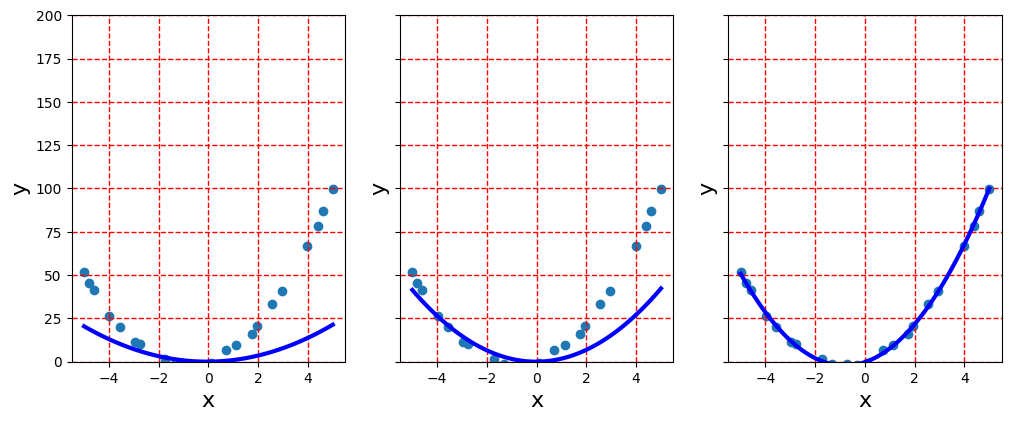

In [20]:
def Draw(ax, w):
    x = np.linspace(-5, 5, 100)
    y = np.zeros(100)
    for i in range(len(w)):
        y = y + w[i]*x**i

    # 設定小圖 ax 的坐標軸標籤, 格線顏色、種類、寬度, y軸繪圖範圍, 最後用 plot 繪圖
    ax.set_xlabel('x', fontsize = 16)
    ax.set_ylabel('y', fontsize = 16)
    ax.grid(color = 'red', linestyle = '--', linewidth = 1)
    ax.set_ylim(0, 200)
    ax.plot(x, y, color = 'blue', linewidth = 3)
    ax.scatter(X, Y)

# 建立繪圖物件 fig, 大小為 12 * 4.5, 內有 1 列 2 欄的小圖, 兩圖共用 x 軸和 y 軸
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharex = True, sharey = True, figsize = (12, 4.5))

Draw(ax1, x1)
Draw(ax2, x2)
Draw(ax3, x3)

# 用 savefig 儲存圖片, 用 show 顯示圖片
fig.savefig('Result.png')
fig.show()